In [1]:
import sys

repo_path = '/home/emaragliano/Work/Projects/Dottorato/baorecon'
sys.path.insert(0, repo_path)

import os
import numpy as np
import matplotlib.pyplot as plt

from zeldareco.pipeline import ReconstructionPipeline

/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
pipeline = ReconstructionPipeline(
    config_file='bao_pipeline_example.yaml',
)

2026-05-27 01:47:54,141 - zeldareco.io.config - INFO - Loaded reconstruction config from bao_pipeline_example.yaml


In [3]:
data_path, random_path = pipeline.run()

2026-05-27 01:47:54,580 - zeldareco.io.catalog_io - INFO - Loaded catalogs: data=736756, random=37694049
2026-05-27 01:47:56,913 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - mean data pos: [ 871.43634 1137.8928  1732.5076 ]
2026-05-27 01:47:57,292 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - mean random pos: [ 874.7463   929.35333 1452.5864 ]
2026-05-27 01:47:58,981 - zeldareco.utils.formatters - INFO - Rectangular box not yet supported. Setting box size to [2480.7522, 2480.7522, 2480.7522] based on maximum separation in positions with padding 100.0.
2026-05-27 01:47:58,982 - zeldareco.BAOreconstruction.density_manager - INFO - Box size not provided. Set to [2480.7522 2480.7522 2480.7522] based on positions with padding 100.0.
2026-05-27 01:48:02,153 - zeldareco.utils.formatters - INFO - Setting box centre to [ 871.27386 1132.7152  1658.367  ] from position range
2026-05-27 01:48:02,154 - zeldareco.BAOreconstruction.density_manager - INFO - Box centre not provid

In [4]:
data_path

'/home/emaragliano/myfarm-disk/LE3-reconstruction/test_pipeline_outputs/rec_sample_survey_ifft_n512_z1.00_data.fits'

In [5]:
# read saved catalogs
from astropy.io import fits
rec_data = fits.open(data_path)


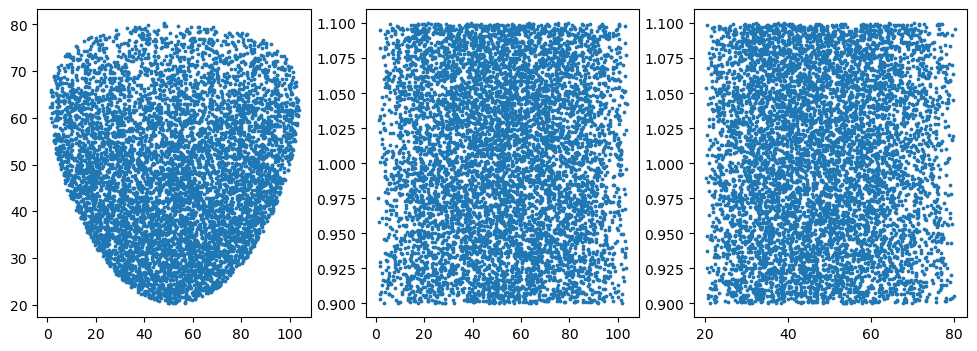

In [6]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].scatter(
    rec_data[1].data['RA'][::100],
    rec_data[1].data['DEC'][::100],
    s=3
)

axs[1].scatter(
    rec_data[1].data['RA'][::100],
    rec_data[1].data['REDSHIFT'][::100],
    s=3
)

axs[2].scatter(
    rec_data[1].data['DEC'][::100],
    rec_data[1].data['REDSHIFT'][::100],
    s=3
)